In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams,ticker,gridspec
import random
import time
from IPython.display import clear_output
from sklearn.neighbors import KernelDensity
import glob
import seaborn as sns
from astropy import units as u
from astropy.coordinates import SkyCoord
import multiprocessing
import collections
from shapely.geometry import Point
from matplotlib.path import Path
import colorcet as cc
from itertools import chain
import sys

#below for netflow
from __future__ import print_function
import ets_fiber_assigner.netflow as nf
from ics.cobraOps.Bench import Bench
from ics.cobraOps.TargetGroup import TargetGroup
from ics.cobraOps.CobrasCalibrationProduct import CobrasCalibrationProduct
from ics.cobraOps.CollisionSimulator import CollisionSimulator
from ics.cobraOps.cobraConstants import NULL_TARGET_POSITION, NULL_TARGET_ID
from ics.cobraOps import plotUtils
from collections import defaultdict

# read samples

In [101]:
def readSamples(direc,print_out):
    '''Read samples from the files: 
    in format of #ID, #RA, #DEC, #exposure, #length, #SciencePriority, #ScienceRank, #note

    Parameters
    ==========
    direc : string
        the name of directory containing sample lists

    Returns
    =======
    list of targets
    '''
    dir_=glob.glob(direc+'/*')
    allSamp=[]
    conA=0
    conB=0
    conC=0
    for l in dir_:
        temp=np.loadtxt(l,dtype='str')
        # convert rank: rankA=3, rankB=2, rankC=1 (currently Calib=0)
        if temp[0,4]=='A':
            rank=3
            rank_t='A'+str(conA+1)
            conA+=1
        elif temp[0,4]=='B':
            rank=2
            rank_t='B'+str(conB+1)
            conB+=1
        elif temp[0,4]=='C':
            rank=1
            rank_t='C'+str(conC+1)
            conC+=1
        else:
            rank=0
            rank_t=temp[0,4]
        if print_out==True:print(l,rank_t,rank)
        for i in temp:
            ID,ra,dec,exp,leng,note=i[0],float(i[1]),float(i[2]),float(i[3]),len(temp),i[-1]                
            # currently one exposure set to be 900 sec.   
            allSamp.append([ID,ra,dec,exp/900.,leng,rank,rank_t,note])  
    return np.array(allSamp, dtype="O") 

In [103]:
#test reading samples
samples=readSamples('sample_inuse/',True)
#cal=readSamples('calib/Fstar/',True)
#sky=readSamples('calib/sky/',True)

sample_inuse/z4lbg_2_ B1 2
sample_inuse/z3qso_sdss B2 2
sample_inuse/star_ishi B3 2
sample_inuse/Oguri_2 C1 1
sample_inuse/z4qso A1 3
sample_inuse/RG A2 3
sample_inuse/RG_ B4 2
sample_inuse/rand_ C2 1
sample_inuse/star_ishi_ A3 3
sample_inuse/z4lbg_1 A4 3
sample_inuse/clust2 A5 3
sample_inuse/clust1 B5 2
sample_inuse/z4qso_ B6 2
sample_inuse/z4lbg_2 A6 3
sample_inuse/z4lbg_1_ B7 2


In [104]:
def count_N(sample):
    '''determine density map
    ## sky regions currently set to be 0<ra<360, -15<dec<80 --> fit with test samples
    
    Parameters
    ==========
    sample : array
        list of targets (id,ra,dec,exp,length,rank,note)
    
    Returns
    =======
    density map; N at grid(ra, dec), bin width= 2 deg
    '''
    count_bin=[ [ 0 for i in np.arange(0,361,2) ] for j in np.arange(-15,80,2) ]
    for tt in range(len(sample)):
        if sample.T[2][tt]<-15 or sample.T[2][tt]>80: continue
        m= int(sample.T[1][tt]/2.) 
        n= int((sample.T[2][tt]+15)/2.)-1
        count_bin[n+1][m]+=1
    return count_bin

def weight(sample,conta,contb,contc): 
    '''calculate weight of target

    Parameters
    ==========
    sample : array
        list of targets (id,ra,dec,exp,length,rank,note)
    conta,contb,contc : float
        parameters of weighting scheme-- conta>0 (contb is recommended to be <=0)

    Returns
    =======
    list of weights
    '''
    rank=sample.T[5]
    count_sam=count_N(sample)
    leng=np.array([count_sam[int((sample.T[2][ii]+15)/2.)][int(sample.T[1][ii]/2.)] for ii in range(len(sample))])
    time_remain=sample.T[3]
    
    if conta<=0: 
        print("Science rank should be positive!!")
        sys.exit()       
    else:
        W1=pow(conta,rank)            #science weight
    W2=pow(time_remain,contb)         #exposure weight
    W3=pow(leng,contc)                #local density weight

    W_tot=W1*W2*W3
    return W_tot

In [105]:
#test determining weights of test samples
weight_=weight(samples,10,-0.2,0.1)

#  KDE part

In [106]:
def PFS_FoV_plot(raP,decP,PA,line_color,line_width,line_st):
    '''plot PFS FoV

    Parameters
    ==========
    raP,decP,PA,line_width : float
        ra, dec, PA of the pointing; width of line for plotting
    line_color,line_st : str
        color and style of line for plotting

    Returns
    =======
    plot PFS FoV
    '''
    center=SkyCoord(raP*u.deg,decP*u.deg)
    #PA=0 along y-axis, PA=90 along x-axis, PA=180 along -y-axis...
    hexagon=center.directional_offset_by([30+PA,90+PA,150+PA,210+PA,270+PA,330+PA,30+PA]*u.deg,1.38/2.*u.deg)
    ra_h=hexagon.ra.deg
    dec_h=hexagon.dec.deg
    
    #for pointings at edges
    ra_h_in=np.where(np.fabs(ra_h-center.ra.deg)>180)
    if len(ra_h_in[0])>0:
        if ra_h[ra_h_in[0][0]]>180:ra_h[ra_h_in[0]]-=360
        elif ra_h[ra_h_in[0][0]]<180:ra_h[ra_h_in[0]]+=360
            
    plt.plot(ra_h,dec_h,color=line_color,lw=line_width,ls=line_st,zorder=100)
    
def PFS_FoV(ra,dec,PA,sample):
    '''select targets in the PFS FoV

    Parameters
    ==========
    sample : array
        list of targets (id,ra,dec,exp,length,rank,note)
    ra,dec,PA : float
        ra, dec, PA of the pointing

    Returns
    =======
    list of index of targets covered by the pointing
    '''
    point=np.vstack((sample.T[1],sample.T[2])).T.astype('float')
    center=SkyCoord(ra*u.deg,dec*u.deg)
    #PA=0 along y-axis, PA=90 along x-axis, PA=180 along -y-axis...
    hexagon=center.directional_offset_by([30+PA,90+PA,150+PA,210+PA,270+PA,330+PA,30+PA]*u.deg,1.38/2.*u.deg)
    ra_h=hexagon.ra.deg
    dec_h=hexagon.dec.deg
    
    #for pointings at edges
    ra_h_in=np.where(np.fabs(ra_h-center.ra.deg)>180)
    if len(ra_h_in[0])>0:
        if ra_h[ra_h_in[0][0]]>180:ra_h[ra_h_in[0]]-=360
        elif ra_h[ra_h_in[0][0]]<180:ra_h[ra_h_in[0]]+=360
            
    polygon = Path([(ra_h[t],dec_h[t]) for t in range(len(ra_h))])
    index_=np.where(polygon.contains_points(point)==True)[0]
    return index_
   
def initial_peak(sample_,Npoint,print_out,conta,contb,contc):
    '''determine the initial guess of pointing centers (randomly pick up targets as the pointing centers)

    Parameters
    ==========
    sample_ : array
        list of targets (id,ra,dec,exp,length,rank,note)
    Npoint : float
        total number of pointings
    print_out : True or False
    conta,contb,contc : float
        parameters of weighting scheme-- conta>0 (contb is recommended to be <=0)

    Returns
    =======
    list of pointing centers
    '''
    samp=[name for name,con in collections.Counter(sample_.T[-2]).items()]
    samp.sort()
    Nfiber=int(2394*0.7)
    
    ii=0
    peak=[]
    sampling=[0]*len(samp)
    sample_s=np.array([uu for uu in sample_])
    while ii<Npoint:
        #sum(sampling_r[:7])/Na<0.6:
        sample_te=np.array([np.append(sample_s[ooo],ooo) for ooo in range(len(sample_s)) if sample_s[ooo,3]>0])
        weight_te=weight(sample_te,conta,contb,contc)
        Sample_t=np.array([np.append(sample_te[uu],weight_te[uu]) for uu in range(len(weight_te))])
        #-------------------------------
        ####peak_xy from random object positions with weights
        ittt=random.choices(np.arange(0,len(Sample_t),1),weights=weight_te.astype(float),k=1)
        peak_x,peak_y=Sample_t[ittt[0]][1],Sample_t[ittt[0]][2]
        #-------------------------------
        index_1=PFS_FoV(peak_x,peak_y,0,Sample_t)
        peak.append([peak_x,peak_y])
        index_=Sample_t.T[-2][index_1]
        
        if len(index_)>Nfiber:
            ttt=random.sample(list(index_), Nfiber)
            sample_s[ttt,3]-=1
        else:
            sample_s[list(index_),3]-=1
        ii+=1
    
        #check sampling ------------------------------
        if print_out==True:
            sampling_full=np.array([collections.Counter(sample_.T[-2])[ee] for ee in samp])
            sampling+=np.array([len([1 for rr in list(index_) if sample_s[rr,-2]==samp[o] and sample_s[rr,3]==0]) \
                    for o in range(len(samp))])
            sampling_r=sampling/sampling_full
            sampling_r[np.isnan(sampling_r)]=0
            sampling_rABC=[np.mean([sampling_r[ee] for ee in range(len(samp)) if samp[ee][0]==ww]) for ww in ['A','B','C']]
            print(str(ii),len(index_),len(sample_te),peak_x,peak_y, "RankA=","{:2.2f}%".format(100*sampling_rABC[0]),\
              ", RankB=","{:2.2f}%".format(100*sampling_rABC[1]),\
              ", RankC=","{:2.2f}%".format(100*sampling_rABC[2]))
        
    print("####---------Determine initial peaks done!")
    return peak

# netflow

In [113]:
def sam2netflow(sample,prefix):
    '''read samples and send to netflow

    Parameters
    ==========
    sample : array
        list of targets (id,ra,dec,exp,length,rank,note)
    prefix : 'sci' or 'cal' or 'sky'
        class of targets
    
    Returns
    =======
    list of targets readable to netflow
    '''
    res=[]
    for tt in sample:
        id_, ra, dec, tm, pri = (tt[0], float(tt[1]), float(tt[2]),float(tt[3])*900.0, tt[6])
        if prefix=='sci':
            res.append(nf.ScienceTarget(id_, ra, dec, tm, pri, prefix))
        else:
            res.append(nf.CalibTarget(id_, ra, dec, prefix))
    return res

def NetflowPreparation(sample,conta,contb,contc,prefix):
    '''set up cost for netflow

    Parameters
    ==========
    sample : array
        list of targets (id,ra,dec,exp,length,rank,note)
    conta,contb,contc : float
        parameters of weighting scheme-- conta>0 (contb is recommended to be <=0)
    prefix : 'sci' or 'cal' or 'sky'
        class of targets

    Returns
    =======
    dictionary of cost functions
    '''
    samp=[name for name,con in collections.Counter(sample.T[-2]).items()]
    samp.sort()
    weight_tem=weight(sample,conta,contb,contc)
    weight_t=np.array([[samp[ii],weight_tem[np.where(sample.T[-2]==samp[ii])[0]][0]] for ii in range(len(samp))])
    if prefix=='sci':
        classdict = {}
        for yy in range(len(weight_t)):
            classdict["sci_P"+weight_t[yy,0]] = {"nonObservationCost": float(weight_t[yy,1]),\
                           "partialObservationCost": float(weight_t[yy,1])*1.2, "calib": False}
    elif prefix=='cal':
        classdict = {}
        classdict["cal"] = {"numRequired": 20,"nonObservationCost": max(weight_tem)*100, "calib": True}
    elif prefix=='sky':
        classdict = {}
        classdict["sky"] = {"numRequired": 20,"nonObservationCost": max(weight_tem)*100, "calib": True}
    return classdict

def netflowRun(Pointing,sample,Fst,sky,t_obs,posang,nvisit,gurobiPa,weightPa):
    '''run netflow

    Parameters
    ==========
    Pointing : array
        list of pointings [ra1,dec1,ra2,dec2, ra3, dec3....]
    posang : array
        list of PA of pointings 
    sample : array
        list of targets (id,ra,dec,exp,length,rank,note)
    Fst,sky : array
        list of Fstars & skys (id,ra,dec)
    weightPa : list [conta,contb,contc]
        parameters of weighting scheme-- conta>0 (contb is recommended to be <=0)
    t_obs,nvisit : int  
        exposure time of one frame; total number of pointings
    gurobiPa : 
        setup of Gurobi parameters

    Returns
    =======
    Objective value, fiber assignment of each pointing
    '''
    time_start=time.time()
    Telra=[Pointing[yy] for yy in range(len(Pointing)) if yy%2==0]
    Teldec=[Pointing[yy] for yy in range(len(Pointing)) if yy%2!=0]
    sample_index=list(chain.from_iterable([list(PFS_FoV(Telra[iii],Teldec[iii],0,sample)) for iii in range(len(Telra))]))
    sample_inuse=sample[list(set(sample_index))]
    #Fst_index=list(chain.from_iterable([list(PFS_FoV(Telra[iii],Teldec[iii],0,Fst)) for iii in range(len(Telra))]))
    #Fst_inuse=Fst[list(set(Fst_index))]
    #sky_index=list(chain.from_iterable([list(PFS_FoV(Telra[iii],Teldec[iii],0,sky)) for iii in range(len(Telra))]))
    #sky_inuse=Fst[list(set(sky_index))]
    print("####number of targets covered by the pointings:",len(sample_inuse))
    #print("####number of Fstars covered by the pointings:",len(Fst_inuse))
    #print("####number of blank sky positions covered by the pointings:",len(sky_inuse))
    bench = Bench(layout="full")
    tgt=sam2netflow(sample_inuse,'sci')
    #tgt+=sam2netflow(Fst_inuse,'cal')
    #tgt+=sam2netflow(sky_inuse,'sky')
    classdict=NetflowPreparation(sample_inuse,weightPa[0],weightPa[1],weightPa[2],'sci')
    #classdict2=NetflowPreparation(sample_inuse,weightPa[0],weightPa[1],weightPa[2],'cal')
    #classdict3=NetflowPreparation(sample_inuse,weightPa[0],weightPa[1],weightPa[2],'sky')
    #classdict={**classdict1, **classdict2,**classdict3}
    
    otime = "2022-04-03T08:00:00"
    telescopes = []
    for kk in range(min(nvisit,len(Telra))):
        telescopes.append(nf.Telescope(Telra[kk], Teldec[kk], posang[kk], otime))
    tpos = [tele.get_fp_positions(tgt) for tele in telescopes]

    # optional: slightly increase the cost for later observations,
    # to observe as early as possible
    vis_cost = [i*3 for i in range(nvisit)]

    # optional: penalize assignments where the cobra has to move far out
    def cobraMoveCost(dist):
        return 0.1*dist

    gurobiOptions = gurobiPa

    # partially observed? no
    alreadyObserved={}

    # compute observation strategy
    prob = nf.buildProblem(bench, tgt, tpos, classdict, t_obs,
                       vis_cost, cobraMoveCost=cobraMoveCost,
                       collision_distance=2., elbow_collisions=True,
                       gurobi=True, gurobiOptions=gurobiOptions,
                       alreadyObserved=alreadyObserved)

    #print("solving the problem")
    prob.solve()
    Obj=prob._prob.objVal

    # extract solution
    res = [{} for _ in range(min(nvisit,len(Telra)))]
    for k1, v1 in prob._vardict.items():
        if k1.startswith("Tv_Cv_"):
            visited = prob.value(v1) > 0
            if visited:
                _, _, tidx, cidx, ivis = k1.split("_")
                res[int(ivis)][int(tidx)] = int(cidx)

    #print fiber assign
    obj_allo=[]
    for i, (vis, tp, tel) in enumerate(zip(res, tpos, telescopes)):
        print("exposure {}:".format(i))
        print("  assigned Cobras: {}".format(len(vis)))
        print("  assigned Cobras(%): {:.2f}%".format(len(vis)/2394.*100))
        for tidx, cidx in vis.items():
            obj_allo.append(["Point"+str(i+1), tel._ra, tel._dec, tel._posang,tgt[tidx].ID,
                             cidx+1, tp[tidx].real, tp[tidx].imag,tgt[tidx].ra, tgt[tidx].dec,
                             tgt[tidx].targetclass])
    print("################---------Run netflow done!")
    return Obj,obj_allo#'''   

# test

In [112]:
%%time
npoint=5
peak_tot=initial_peak(samples,npoint,True,10,-0.2,0.1)
gurobiPa=dict(seed=0, presolve=1, method=0, degenmoves=0,heuristics=0.6, mipfocus=0, mipgap=5.0e-2,\
              PreSOS2Encoding=0,PreSOS1Encoding=0)#,LogToConsole=0)
Obj,obj_allo=netflowRun(list(chain.from_iterable(peak_tot)),samples,0,0,900,[0]*npoint,npoint,gurobiPa,[10,-0.2,0.1])

1 20106 246286 34.87885 -4.93417 RankA= 0.36% , RankB= 0.00% , RankC= 0.00%
2 11271 244622 34.353967 -4.00227 RankA= 0.73% , RankB= 0.00% , RankC= 0.00%
3 16858 242957 33.947736 -5.14799 RankA= 1.10% , RankB= 0.00% , RankC= 0.00%
4 3358 241288 35.356414 -6.38053 RankA= 1.46% , RankB= 0.00% , RankC= 0.00%
5 17265 239641 34.74831 -5.40163 RankA= 1.82% , RankB= 0.00% , RankC= 0.00%
####---------Determine initial peaks done!
####number of targets covered by the pointings: 52178
Set parameter Presolve to value 1
Set parameter Method to value 0
Set parameter DegenMoves to value 0
Set parameter Heuristics to value 0.6
Set parameter MIPGap to value 0.05
Set parameter PreSOS2Encoding to value 0
Set parameter PreSOS1Encoding to value 0
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
  exposure 2
Calculating visibilities
adding constraints
adding collision constraints
  exposure 3
Calculating visibilities
adding constraints
adding co

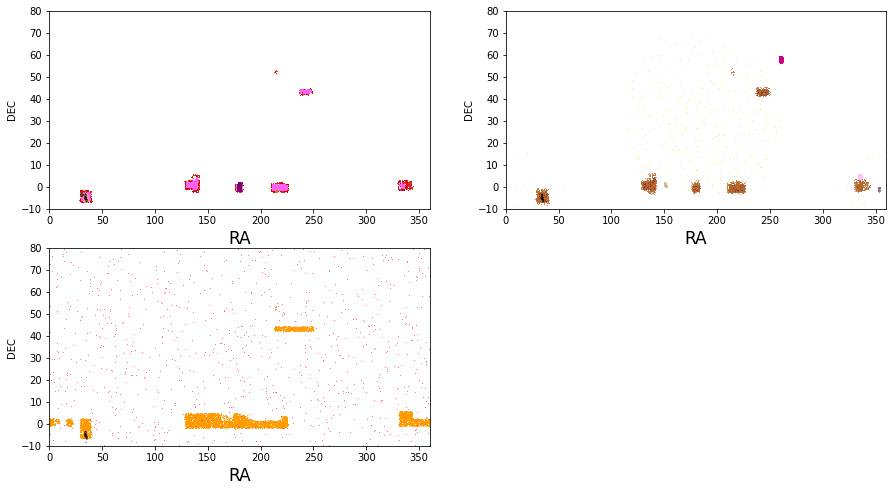

In [122]:
#plot
rcParams['figure.figsize'] = 15,8
samp=[name for name,con in collections.Counter(samples.T[-2]).items()]
samp.sort()
palette = sns.color_palette(cc.glasbey_warm, len(samp))

def plot_netflow(ii,rank):
    plt.subplot(2,2,ii)
    for o in range(len(samp)):
        if samp[o][0]!=rank:continue
        plt.plot([samples[rr,1] for rr in range(len(samples)) if samples[rr][-2]==samp[o]],\
                [samples[rr,2] for rr in range(len(samples)) if samples[rr][-2]==samp[o]],\
                'o',mfc=palette[o],mec='none',ms=1)
    
    ra_P=np.array(peak_tot)[:,0]
    dec_P=np.array(peak_tot)[:,1]
    for t in range(1,len(ra_P)):
        PFS_FoV_plot(ra_P[t],dec_P[t],0,'k',0.7,'-')
    plt.xlabel('RA',fontsize=17)
    plt.ylabel('DEC',fontsize=10)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)  
    plt.xlim(0,360)
    plt.ylim(-10,80)

plot_netflow(1,'A')
plot_netflow(2,'B')
plot_netflow(3,'C')

#plt.savefig('/home/wanqiu/Dropbox/PFS_framework/sample.jpg',dpi=300,bbox_inches='tight')
plt.show()

In [124]:
#check the number of allocated Fstars and skies in each pointing
N_p=['Point'+str(i) for i in np.arange(1,nvisit+1,1)]
cal_assign=[len([1 for rr in range(len(obj_allo)) \
                                       if obj_allo[rr][0]==N_p[mm] and obj_allo[rr][-1]=='cal'])\
          for mm in range(len(N_p))]
sky_assign=[len([1 for rr in range(len(obj_allo)) \
                                       if obj_allo[rr][0]==N_p[mm] and obj_allo[rr][-1]=='sky'])\
          for mm in range(len(N_p))]
for i in range(len(N_p)):
    print("Pointing {:3d}: assigned Fstars {:5d}; assigned skies {:5d}".format(i+1,cal_assign[i],sky_assign[i]))

Pointing   1: assigned Fstars     0; assigned skies     0
Pointing   2: assigned Fstars     0; assigned skies     0
Pointing   3: assigned Fstars     0; assigned skies     0
Pointing   4: assigned Fstars     0; assigned skies     0
Pointing   5: assigned Fstars     0; assigned skies     0


['Point1', 'Point2', 'Point3', 'Point4', 'Point5']


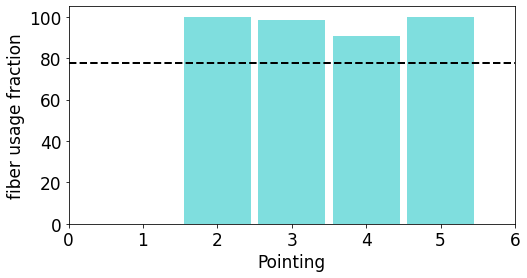

In [48]:
#plot efficiency of fiber usage
rcParams['figure.figsize'] = 8,4
nvisit=5
N_p=['Point'+str(i) for i in np.arange(1,nvisit+1,1)]
print(N_p)
fib_eff1=[len([1 for rr in range(len(obj_allo)) \
                                       if obj_allo[rr][0]==N_p[mm]])/2394.*100 for mm in range(len(N_p))]
plt.bar(np.arange(1,len(N_p)+1,1),fib_eff1,width=0.9,fc='c',alpha=0.5)
plt.plot([0,200],[np.mean(fib_eff1),np.mean(fib_eff1)],'k--',lw=2)
plt.xlabel('Pointing',fontsize=17)
plt.ylabel('fiber usage fraction',fontsize=17)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)  
plt.xlim(0,len(N_p)+1)
plt.ylim(0,105)
#plt.savefig('/home/wanqiu/Dropbox/PFS_framework/effi_.jpg',dpi=300)
plt.show()

In [38]:
#check assigned targets
sample_=np.array([uu for uu in samples])
for qq in range(len(obj_allo)):
    sample_.T[3][np.where(sample_.T[0]==obj_allo[qq][4])[0]]-=1

sample_inuse/z4lbg_2_ B1 2
sample_inuse/z3qso_sdss B2 2
sample_inuse/star_ishi B3 2
sample_inuse/Oguri_2 C1 1
sample_inuse/z4qso A1 3
sample_inuse/RG A2 3
sample_inuse/RG_ B4 2
sample_inuse/rand_ C2 1
sample_inuse/star_ishi_ A3 3
sample_inuse/z4lbg_1 A4 3
sample_inuse/clust2 A5 3
sample_inuse/clust1 B5 2
sample_inuse/z4qso_ B6 2
sample_inuse/z4lbg_2 A6 3
sample_inuse/z4lbg_1_ B7 2


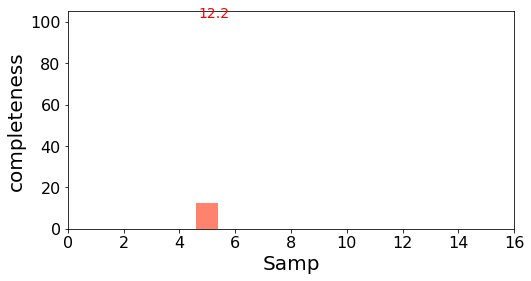

In [51]:
samples=readSamples('sample_inuse/',True)

plt.figure(figsize=(8,4))

samp=[name for name,con in collections.Counter(samples.T[-2]).items()]
samp.sort()

for o in range(len(samp)):
    value=len([1 for rr in range(len(sample_)) if sample_[rr][-2]==samp[o] and sample_[rr][3]<=0])/\
            len([1 for rr in range(len(sample_)) if sample_[rr][-2]==samp[o]])*100
    plt.bar(o,value,width=0.8,fc='tomato',ec='none',alpha=0.8)
    if value>10.:
        plt.text(o-0.3,102,'{:2.1f}'.format(value),fontsize=14,color='r')

plt.xlim(0,len(samp)+1)
plt.ylim(0,105)
plt.xlabel('Samp',fontsize=20)
plt.ylabel('completeness',fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
#plt.savefig('/home/wanqiu/Dropbox/PFS_framework/sample.jpg',dpi=300,bbox_inches='tight')
plt.show()